In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Wireless Environment Parameters ---
N0_DBM_HZ = -174         # Noise density [cite: 462]
P_TX_CLIENT_DBM = 24     # Uplink Power [cite: 462]
P_TX_SERVER_DBM = 46     # Downlink Power (Server) [cite: 462]
Q_BITS = 16              # 16-bit quantization [cite: 463]
RADIUS_KM = 0.5          # 500m [cite: 459]
DEVICE_GFLOPS = 2.0      # Average edge device speed [cite: 262]

# --- 2. Model Architectures ---
class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

# --- 3. Probabilistic Scheduling Logic ---
def get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho):
    n_total = sum(n_k_list)
    grad_norms = np.array(grad_norms) + 1e-12 
    T_u_list = np.array(T_u_list)

    if rho == 0: return np.ones(len(n_k_list)) / len(n_k_list)
    if rho == 1:
        p = (np.array(n_k_list) / n_total) * grad_norms
        return p / np.sum(p)

    def compute_p_star(lam):
        denom = (1 - rho) * T_u_list + lam
        return (np.array(n_k_list) / n_total) * grad_norms * np.sqrt(rho / np.maximum(denom, 1e-15))

    low, high = -np.min((1 - rho) * T_u_list) + 1e-12, 1e6
    for _ in range(50):
        mid = (low + high) / 2
        if np.sum(compute_p_star(mid)) > 1: low = mid
        else: high = mid
    final_p = compute_p_star(high)
    return final_p / np.sum(final_p)

def get_multi_device_selection(n_k_list, grad_norms, T_u_list_full_B, rho, M):
    p_star = get_optimal_probabilities(n_k_list, grad_norms, T_u_list_full_B, rho)
    selected_indices = []
    current_p = p_star.copy()
    for m in range(M):
        current_p = current_p / np.sum(current_p)
        idx = np.random.choice(range(len(p_star)), p=current_p)
        selected_indices.append(idx)
        current_p[idx] = 0
    return selected_indices, p_star

# --- 4. Data Preparation ---

def get_datasets(task='SVM'):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
    # Filter classes 0 (airplane) and 1 (automobile)
    train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
    test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
        
    # 15 devices get only airplanes, 15 get only automobiles (330 samples each)
    airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*330]
    autos = [i for i in train_idx if train_set.targets[i] == 1][:15*330]
        
    device_data = [Subset(train_set, airplanes[i*330:(i+1)*330]) for i in range(15)] + \
                      [Subset(train_set, autos[i*330:(i+1)*330]) for i in range(15)]
        
    return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001
    
def run_multi_device_fl_time_constrained(task='SVM', rho=5e-6, M=10, bandwidth=1e6, max_time=5.0):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    n_k_list = [len(d) for d in device_data]
    n_total = sum(n_k_list)
    lmbda = 0.01 
    r_km = RADIUS_KM * np.sqrt(np.random.rand(30)) 
    history = {'acc': [], 'time': []}
    cumulative_time = 0
    round_count = 0

    print(f"\n--- Simulation: {task} | 30 Clients | {max_time} Seconds ---")

    # Change: Loop based on time instead of rounds [cite: 614]
    while cumulative_time < max_time:
        # Step 1: Wireless Environment
        path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
        noise_w = 10**(((N0_DBM_HZ + 10 * np.log10(bandwidth)) - 30) / 10)
        p_rx_up_w = 10**(((P_TX_CLIENT_DBM - path_loss_db) - 30) / 10)
        gamma_up = p_rx_up_w / noise_w
        p_rx_down_w = 10**(((P_TX_SERVER_DBM - path_loss_db) - 30) / 10)
        gamma_down_min = np.min(p_rx_down_w / noise_w)
        
        num_params = sum(p.numel() for p in global_model.parameters())
        payload_bits = num_params * Q_BITS
        T_u_full_B = payload_bits / (bandwidth * np.log2(1 + gamma_up))

        # Steps 2 & 3: Importance Evaluation [cite: 180, 277]
        grad_norms, client_gradients = [], []
        for i in range(30):
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            loader = DataLoader(device_data[i], batch_size=len(device_data[i]))
            data, target = next(iter(loader))
            local_model.zero_grad()
            output = local_model(data).squeeze()
            target_svm = (target.float() * 2) - 1 
            loss = 0.5 * torch.mean(torch.clamp(1 - target_svm * output, min=0)) + (lmbda/2.0) * sum(p.pow(2).sum() for p in local_model.parameters())
            loss.backward()
            grads = [p.grad.detach().clone() for p in local_model.parameters()]
            grad_norms.append(torch.norm(torch.cat([g.view(-1) for g in grads])).item())
            client_gradients.append(grads)

        # Step 4 & 5: Selection and Equalized Latency [cite: 377, 437]
        selected_indices, p_star = get_multi_device_selection(n_k_list, grad_norms, T_u_full_B, rho, M)
        R_k = np.log2(1 + gamma_up[selected_indices])
        t_upload_equalized = (payload_bits / bandwidth) * np.sum(1.0 / R_k)
        t_broadcast = payload_bits / (bandwidth * np.log2(1 + gamma_down_min))
        t_comp_max = (max(n_k_list) * 6000) / (DEVICE_GFLOPS * 1e9)
        
        # Add round time to cumulative budget [cite: 279]
        round_time = t_broadcast + t_comp_max + t_upload_equalized
        cumulative_time += round_time
        round_count += 1

        # Step 6: Global Update [cite: 380]
        with torch.no_grad():
            global_grad_sum = [torch.zeros_like(p) for p in global_model.parameters()]
            for m, idx in enumerate(selected_indices):
                sum_prev_p = sum(p_star[selected_indices[j]] for j in range(m))
                q_Y_m = p_star[idx] / (1.0 - sum_prev_p)
                scale = n_k_list[idx] / (n_total * q_Y_m)
                for g_sum, g_local in zip(global_grad_sum, client_gradients[idx]):
                    g_sum += (1.0 / M) * scale * g_local
            for p_global, g_agg in zip(global_model.parameters(), global_grad_sum):
                p_global -= lr * g_agg

        # Evaluation
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                correct += (torch.sign(output.squeeze()) == (target.float()*2-1)).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        
        if round_count % 5 == 0:
            print(f"M={M} | Time: {cumulative_time:.2f}s / {max_time}s | Acc: {history['acc'][-1]:.4f}")

    return history

def run_fig5_comparison_fixed_time(max_time_1mhz = 1.5, max_time_20mhz = 1.5):
    M_values = [1, 10, 20, 30]
    rho = 5e-6
    
    all_results = {1e6: {}, 20e6: {}}

    # Run Simulation
    for B_val, limit in [(1e6, max_time_1mhz), (20e6, max_time_20mhz)]:
        for M in M_values:
            print(f"\n>>> Running: B={B_val/1e6}MHz, M={M}, Target Time={limit}s")
            all_results[B_val][M] = run_multi_device_fl_time_constrained(
                rho=rho, M=M, bandwidth=B_val, max_time=limit
            )

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for M in M_values:
        ax1.plot(all_results[1e6][M]['time'], all_results[1e6][M]['acc'], label=f'M={M}')
        ax2.plot(all_results[20e6][M]['time'], all_results[20e6][M]['acc'], label=f'M={M}')
    
    ax1.set_title("B = 1 MHz")
    ax1.set_xlabel("Time (s)"), ax1.set_ylabel("Accuracy"), ax1.legend(), ax1.grid(True)
    
    ax2.set_title("B = 20 MHz")
    ax2.set_xlabel("Time (s)"), ax2.set_ylabel("Accuracy"), ax2.legend(), ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# run_fig5_comparison_fixed_time()
# run_fig5_comparison()


>>> Running: B=1.0MHz, M=1, Target Time=300s
Files already downloaded and verified
Files already downloaded and verified

--- Simulation: SVM | 30 Clients | 300 Seconds ---
M=1 | Time: 0.04s / 300s | Acc: 47.3000
M=1 | Time: 0.08s / 300s | Acc: 53.1000
M=1 | Time: 0.12s / 300s | Acc: 56.7000
M=1 | Time: 0.16s / 300s | Acc: 59.6500
M=1 | Time: 0.20s / 300s | Acc: 61.4500
M=1 | Time: 0.23s / 300s | Acc: 61.4500
M=1 | Time: 0.27s / 300s | Acc: 62.1500
M=1 | Time: 0.30s / 300s | Acc: 62.2500
M=1 | Time: 0.34s / 300s | Acc: 62.3500
M=1 | Time: 0.37s / 300s | Acc: 62.3000
M=1 | Time: 0.41s / 300s | Acc: 62.2000
M=1 | Time: 0.44s / 300s | Acc: 62.2000
M=1 | Time: 0.48s / 300s | Acc: 64.2000
M=1 | Time: 0.51s / 300s | Acc: 64.2500
M=1 | Time: 0.55s / 300s | Acc: 65.0000
M=1 | Time: 0.59s / 300s | Acc: 65.0000
M=1 | Time: 0.62s / 300s | Acc: 65.9500
M=1 | Time: 0.66s / 300s | Acc: 66.5000
M=1 | Time: 0.69s / 300s | Acc: 66.5000
M=1 | Time: 0.73s / 300s | Acc: 67.4000
M=1 | Time: 0.77s / 300s |

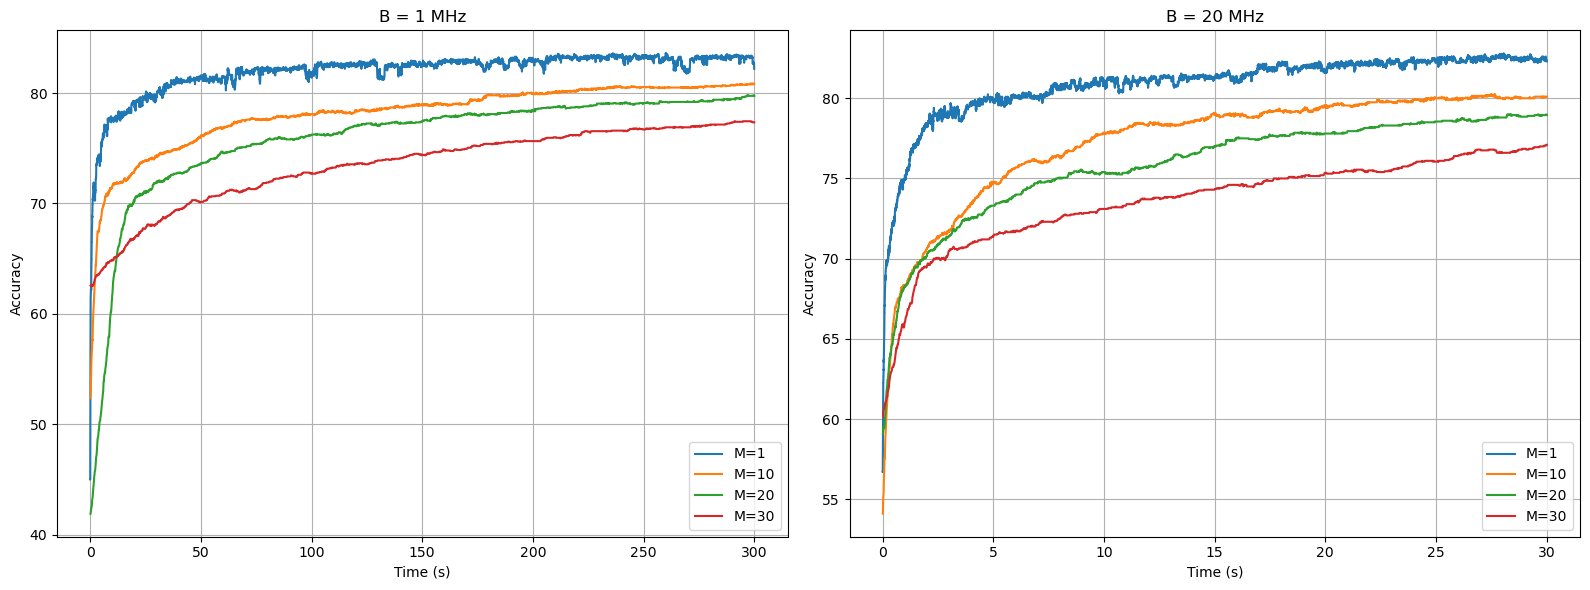

In [21]:
run_fig5_comparison_fixed_time(max_time_1mhz = 300, max_time_20mhz = 30)